<a href="https://colab.research.google.com/github/dev4v/data-science-portfolio/blob/main/image_captioning_using_qwen_3B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/huggingface/transformers.git


In [ ]:
!pip install accelerate safetensors


In [1]:
!nvidia-smi

Mon Sep  8 12:57:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import random
import textwrap
import io
import requests
import numpy as np

# Deep‑learning stack
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoProcessor, AutoModelForVision2Seq

import torch

# Imaging & visualisation
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches



In [3]:
import torch
from transformers import AutoProcessor, AutoTokenizer, AutoModelForVision2Seq

# Model ID
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# Load processor and tokenizer
processor = AutoProcessor.from_pretrained(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

model = AutoModelForVision2Seq.from_pretrained(
    model_id,
    device_map="auto",       #splits model layers across GPUs
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True   # reduces memory usage
)

# Check which devices the model layers are on
for name, param in model.named_parameters():
    if param.device.type == "cuda":
        print(name, param.device)
        break  # just print one as an example


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

model.visual.patch_embed.proj.weight cuda:0


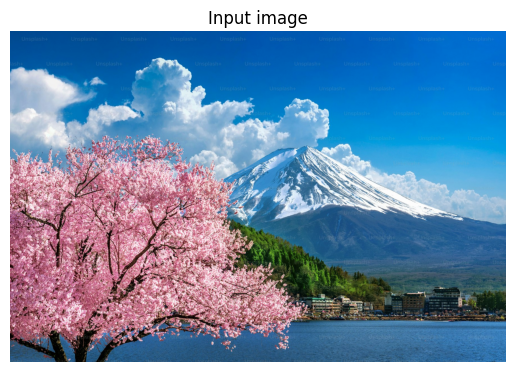

In [4]:
url = "https://plus.unsplash.com/premium_photo-1661964177687-57387c2cbd14?q=80&w=1770&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
img = Image.open(io.BytesIO(requests.get(url, timeout=15).content)).convert("RGB")

# Display the image
plt.figure()
plt.imshow(img)
plt.axis("off")
plt.title("Input image")
plt.show()

In [5]:
msgs = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Describe this image."}
        ],
    }
]

In [6]:
text_prompt = processor.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)



In [7]:
inputs = processor(text=text_prompt, images=img, return_tensors="pt").to(model.device)

# Generate
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=1000)

print(processor.decode(outputs[0], skip_special_tokens=True))

system
You are a helpful assistant.
user
Describe this image.
assistant
The image depicts a stunning natural landscape featuring Mount Fuji, a prominent mountain in Japan. The mountain is covered with snow and has a distinctive conical shape. In the foreground, there is a large tree with vibrant pink blossoms, likely cherry blossoms, which are in full bloom. The tree is situated near a body of water, possibly a lake or river, which reflects the clear blue sky above. The sky is mostly clear with a few scattered clouds, adding to the serene and picturesque quality of the scene. In the background, there are buildings and structures, indicating that this location is near a populated area. The overall atmosphere of the image is tranquil and beautiful, capturing the essence of a peaceful day in a scenic Japanese setting.


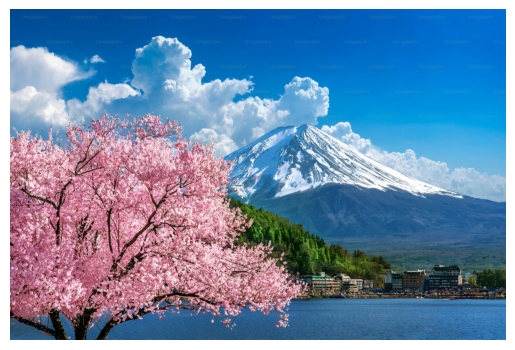

The image depicts a stunning natural landscape featuring Mount Fuji, a prominent
mountain in Japan. The mountain is covered with snow and has a distinctive
conical shape. In the foreground, there is a large tree with vibrant pink
blossoms, likely cherry blossoms, which are in full bloom. The tree is situated
near a body of water, possibly a lake or river, which reflects the clear blue
sky above. The sky is mostly clear with a few scattered clouds, adding to the
serene and picturesque quality of the scene. In the background, there are
buildings and structures, indicating that this location is near a populated
area. The overall atmosphere of the image is tranquil and beautiful, capturing
the essence of a peaceful day in a scenic Japanese setting.


In [8]:
# Extract the newly generated tokens
caption = processor.batch_decode(
    outputs[:, inputs.input_ids.shape[-1]:],
    skip_special_tokens=True
)[0]

# Display the image
plt.figure()
plt.imshow(img)
plt.axis("off")
plt.show()

# Print caption

width = 80
wrapped_caption = textwrap.fill(caption, width)
print(wrapped_caption)